In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import SimpleImputer, KNNImputer, IterativeImputer
import re

In [3]:
df=pd.read_csv("phones.csv")
df.head()

,Company Name,Model Name,Mobile Weight,RAM,Front Camera,Back Camera,Processor,Battery Capacity,Screen Size,Launched Price (USA),Launched Year
0,Apple,iPhone 16 128GB,NaN,6GB,12MP,48MP,A17 Bionic,"3,600mAh",6.1 inches,USD 799,2024
1,Apple,iPhone 16 256GB,174g,6GB,12MP,48MP,A17 Bionic,"3,600mAh",6.1 inches,USD 849,2024
2,Apple,iPhone 16 512GB,174g,6GB,12MP,48MP,A17 Bionic,"3,600mAh",6.1 inches,USD 899,2024
3,NaN,iPhone 16 Plus 128GB,203g,6GB,12MP,48MP,A17 Bionic,"4,200mAh",6.7 inches,USD 899,2024
4,NaN,iPhone 16 Plus 256GB,203g,6GB,12MP,48MP,A17 Bionic,"4,200mAh",6.7 inches,USD 949,2024


In [4]:
len(df)

930

<Axes: >

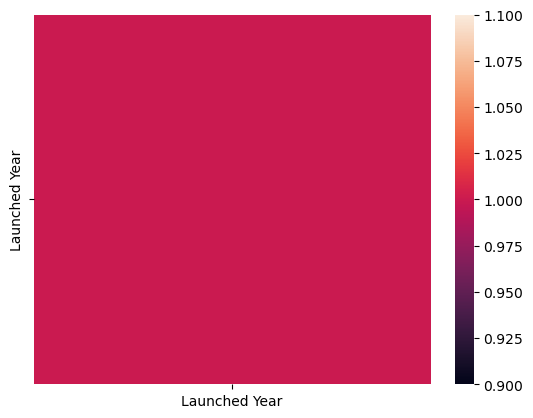

In [6]:
sns.heatmap(df.corr(numeric_only=True))

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 930 entries, 0 to 929
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Company Name          854 non-null    object
 1   Model Name            930 non-null    object
 2   Mobile Weight         733 non-null    object
 3   RAM                   930 non-null    object
 4   Front Camera          930 non-null    object
 5   Back Camera           930 non-null    object
 6   Processor             930 non-null    object
 7   Battery Capacity      930 non-null    object
 8   Screen Size           930 non-null    object
 9   Launched Price (USA)  921 non-null    object
 10  Launched Year         930 non-null    int64 
dtypes: int64(1), object(10)
memory usage: 80.1+ KB


<Axes: xlabel='Company Name'>

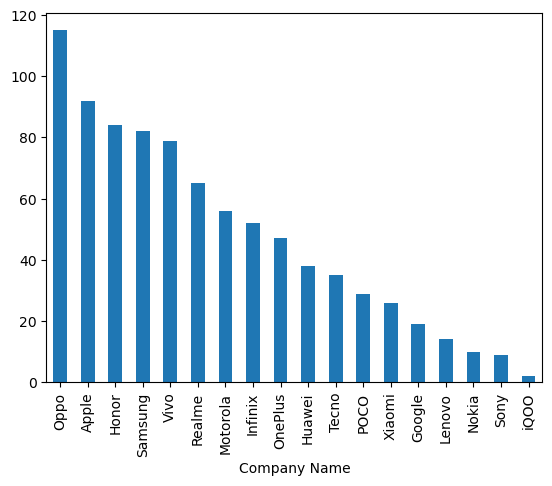

In [8]:
df['Company Name'].value_counts().plot.bar()

<Axes: >

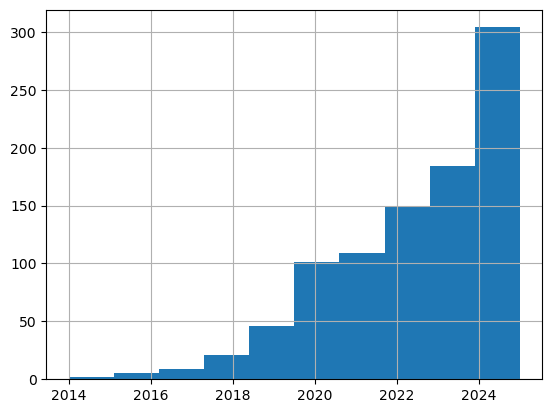

In [10]:
df['Launched Year'].hist()

In [14]:
year_imputer=SimpleImputer(strategy='median')
df[['Launched Year']]=year_imputer.fit_transform(df[['Launched Year']])

In [16]:
df.isnull().sum()

Company Name             76
Model Name                0
Mobile Weight           197
RAM                       0
Front Camera              0
Back Camera               0
Processor                 0
Battery Capacity          0
Screen Size               0
Launched Price (USA)      9
Launched Year             0
dtype: int64

In [17]:
df.dropna(subset=['Launched Price (USA)'],inplace=True)

In [19]:
df.isna().sum()

Company Name             76
Model Name                0
Mobile Weight           196
RAM                       0
Front Camera              0
Back Camera               0
Processor                 0
Battery Capacity          0
Screen Size               0
Launched Price (USA)      0
Launched Year             0
dtype: int64

In [22]:
len(df['Model Name'].unique())

899

In [23]:
df.drop(columns=['Model Name'],inplace=True)

In [37]:
def preprocess_weight(value):
    if not pd.isna(value):
        num=re.findall(r"\d{3}",value)
        return float(num[0])

In [38]:
df['Mobile Weight']=df['Mobile Weight'].apply(preprocess_weight)

In [39]:
df.head()

,Company Name,Mobile Weight,RAM,Front Camera,Back Camera,Processor,Battery Capacity,Screen Size,Launched Price (USA),Launched Year
0,Apple,NaN,6GB,12MP,48MP,A17 Bionic,"3,600mAh",6.1 inches,USD 799,2024.0
1,Apple,174.0,6GB,12MP,48MP,A17 Bionic,"3,600mAh",6.1 inches,USD 849,2024.0
2,Apple,174.0,6GB,12MP,48MP,A17 Bionic,"3,600mAh",6.1 inches,USD 899,2024.0
3,NaN,203.0,6GB,12MP,48MP,A17 Bionic,"4,200mAh",6.7 inches,USD 899,2024.0
4,NaN,203.0,6GB,12MP,48MP,A17 Bionic,"4,200mAh",6.7 inches,USD 949,2024.0


In [40]:
df['RAM'].value_counts()

RAM
8GB           305
6GB           204
12GB          191
4GB           145
3GB            34
16GB           30
2GB             6
1.5GB           2
8GB / 12GB      2
10GB            1
1GB             1
Name: count, dtype: int64

In [46]:
new_rows=[]
for i,row in df.iterrows():
    ram=row['RAM']
    vals=ram.split(" / ")
    for val in vals:
        num=re.findall(r"\d+(?:\.\d+)?",val)
        new_row=row.copy()
        new_row['RAM']=num[0]
        new_rows.append(new_row)
df_new = pd.DataFrame(new_rows).reset_index(drop=True)

In [49]:
df=df_new
df['RAM'].value_counts()

RAM
8      307
6      204
12     193
4      145
3       34
16      30
2        6
1.5      2
10       1
1        1
Name: count, dtype: int64

In [50]:
df['Front Camera'].value_counts()

Front Camera
16MP                                  209
32MP                                  205
8MP                                   165
12MP                                   81
5MP                                    47
13MP                                   45
12MP / 4K                              35
50MP                                   30
7MP                                    24
10MP                                   21
2MP                                    12
20MP                                   11
10.8MP                                  6
60MP                                    5
10.5MP                                  3
44MP                                    3
10MP, 4MP (UDC)                         3
60MP + 8MP                              3
25MP                                    2
60MP (ultrawide) + 8MP (telephoto)      2
20MP+8MP                                2
10.7MP                                  2
12MP + 12MP                             1
24MP                 

In [51]:
def preprocess_screen(value):
    

Screen Size
6.7 inches     123
6.5 inches      75
6.67 inches     68
6.6 inches      63
6.78 inches     61
              ... 
7.85 inches      1
6.34 inches      1
12.0 inches      1
13.5 inches      1
6.79 inches      1
Name: count, Length: 97, dtype: int64